In [25]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [27]:
df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


#TASK 1 — Dataset Understanding



Rows and Columns: (2000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       200

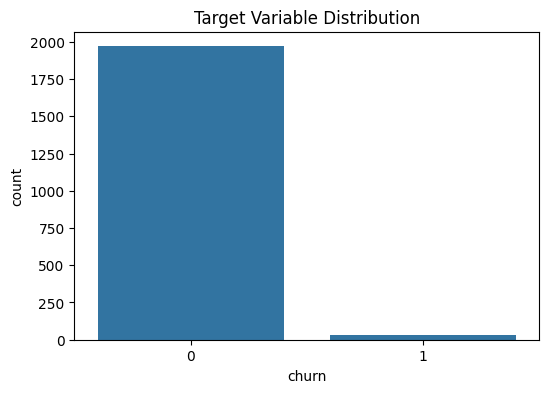

In [28]:
print("Rows and Columns:", df.shape)

df.info()

print(df.isnull().sum())

df.describe()

plt.figure(figsize=(6,4))

sns.countplot(x='churn', data=df)

plt.title("Target Variable Distribution")
plt.savefig("target_distribution.png")
plt.show()

X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# TASK 2 — Data Preprocess

In [29]:
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

numerical_cols = [col for col in X.columns if col not in categorical_cols]


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

#TASK 3 — Neural Network

In [30]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

# TASK 4 — Training and Evaluate

In [32]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5930 - loss: 0.6812 - val_accuracy: 0.9750 - val_loss: 0.3702
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9859 - loss: 0.2393 - val_accuracy: 0.9781 - val_loss: 0.1564
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - loss: 0.1092 - val_accuracy: 0.9781 - val_loss: 0.1091
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - loss: 0.0794 - val_accuracy: 0.9781 - val_loss: 0.1017
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9867 - loss: 0.0713 - val_accuracy: 0.9781 - val_loss: 0.1000
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - loss: 0.0673 - val_accuracy: 0.9781 - val_loss: 0.0991
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9867 - loss: 0.0641 - val_accuracy: 0.9781 - val_loss: 0.0973
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9867 - loss: 0.0619 - val_accuracy: 0.9781 - va

In [33]:
train_loss, train_acc = model.evaluate(X_train, y_train)

test_loss, test_acc = model.evaluate(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9869 - loss: 0.0455
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9825 - loss: 0.0743  
Training Accuracy: 0.9868749976158142
Testing Accuracy: 0.9825000166893005


In [34]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


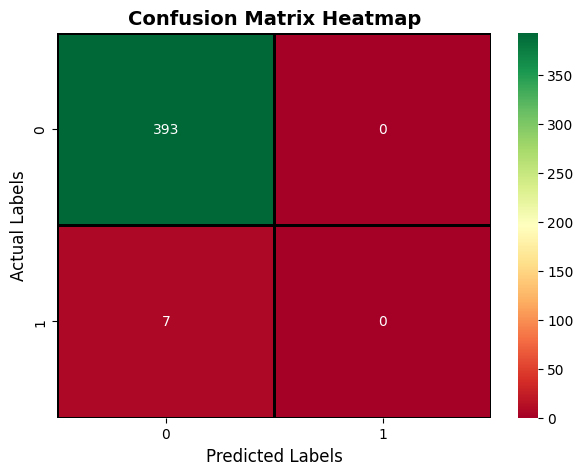

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='RdYlGn',   # Red-Yellow-Green color palette
    linewidths=1,
    linecolor='black',
    cbar=True
)

plt.title("Confusion Matrix Heatmap", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("Actual Labels", fontsize=12)

plt.savefig("evaluation_outputs.png", dpi=300, bbox_inches='tight')

plt.show()

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#TASK 5 — Hyperparameter Experimentation

In [37]:
def build_model(neurons=32, learning_rate=0.001, activation='relu'):

    model = Sequential()

    model.add(Dense(neurons, activation=activation, input_dim=X_train.shape[1]))

    model.add(Dense(16, activation=activation))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [38]:
model1 = build_model(neurons=32, learning_rate=0.001)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=0
)

acc1 = model1.evaluate(X_test, y_test, verbose=0)[1]


model2 = build_model(neurons=64, learning_rate=0.001)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    verbose=0
)

acc2 = model2.evaluate(X_test, y_test, verbose=0)[1]


model3 = build_model(neurons=128, learning_rate=0.0005, activation='tanh')

history3 = model3.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    verbose=0
)

acc3 = model3.evaluate(X_test, y_test, verbose=0)[1]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
comparison = pd.DataFrame({
    'Experiment': ['Exp 1', 'Exp 2', 'Exp 3'],
    'Neurons': [32, 64, 128],
    'Learning Rate': [0.001, 0.001, 0.0005],
    'Activation': ['relu', 'relu', 'tanh'],
    'Batch Size': [32, 16, 32],
    'Epochs': [20, 30, 40],
    'Test Accuracy': [acc1, acc2, acc3]
})

comparison

,Experiment,Neurons,Learning Rate,Activation,Batch Size,Epochs,Test Accuracy
0,Exp 1,32,0.0010,relu,32,20,0.9825
1,Exp 2,64,0.0010,relu,16,30,0.9750
2,Exp 3,128,0.0005,tanh,32,40,0.9825


In [40]:
comparison.to_csv("model_comparison_table.csv", index=False)